# Lesson 9 — The normal distribution & the empirical rule

*Part 1 · Lesson 9 of 20  ·  data: Galton family heights*

**←** [Lesson 8: Binomial & Poisson — counting events](08-binomial-poisson.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  [Lesson 10: Sampling distributions & the Central Limit Theorem](10-sampling-distributions-clt.ipynb) **→**

**Same idea, another way:**  [Another dataset →](09-normal-distribution~another-dataset.ipynb)  ·  [The code behind it →](09-normal-distribution~the-code.ipynb)

**The bell curve is the most famous shape in all of statistics — and today we'll watch real data fall right into it.** We'll use the heights of **934 grown children** from Francis Galton's 1880s family study (the original "bell curve" dataset), draw the smooth normal curve on top, and check the celebrated **68–95–99.7 rule** by counting. The payoff: a **z-score** (how many standard deviations a value sits above or below the average) — which back in Lesson 2 we could only call "unusual" — finally becomes an actual **probability**.

Run each grey cell with **Shift + Enter**, then tinker.

> **New to notebooks?** The grey boxes below are **code**. Click one and press **Shift + Enter** to run it — the result (a number, a table, or a chart) appears right underneath. Run them **top to bottom**. You do **not** need to understand the first *"Setup"* cell — it just loads the tools and the data, so run it and move on. And you **can't break anything**: re-running a cell is always safe. *(Brand new to all this? The five-minute [Lesson 0 — How these notebooks work](00-how-these-notebooks-work.ipynb) shows you the basics first.)*

In [1]:
# --- Setup: load our helpers and the data --------------------------------
import sys, pathlib
for _p in [pathlib.Path.cwd(), pathlib.Path.cwd().parent]:
    if (_p / 'lib' / 'statslab.py').exists():
        sys.path.insert(0, str(_p / 'lib')); break
import statslab as sl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
sl.use_course_style()

GALTON_URL = 'https://vincentarelbundock.github.io/Rdatasets/csv/HistData/GaltonFamilies.csv'
galton = sl.load_csv('galton.csv', url=GALTON_URL)

heights = galton['childHeight']          # adult child height, in inches
mu  = heights.mean()                     # the curve's CENTER
sd  = heights.std(ddof=1)                # the curve's WIDTH (one 'give or take')
print(f'{len(galton)} children measured')
print(f'mean height (mu)      = {mu:.2f} inches')
print(f'standard deviation (sigma) = {sd:.2f} inches')

934 children measured
mean height (mu)      = 66.75 inches
standard deviation (sigma) = 3.58 inches


## 1) The normal curve and its two knobs

A **normal distribution** (the "bell curve") is a smooth, symmetric hump. Remarkably, its *entire* shape is fixed by just **two numbers**:

- $\mu$ (mu) — the **mean**, which sets *where the peak sits*.
- $\sigma$ (sigma) — the **standard deviation**, which sets *how wide* the bell is.

**The math.** The height of the curve at any value $x$ is given by the formula

$$f(x) = \frac{1}{\sigma\sqrt{2\pi}}\; e^{-\frac{1}{2}\left(\frac{x-\mu}{\sigma}\right)^2}.$$

Don't memorize it — notice that the only ingredients are $x$, $\mu$, and $\sigma$. The $\left(\frac{x-\mu}{\sigma}\right)$ inside is exactly the **z-score** from Lessons 1–2: "how many SDs from the mean."

**The meaning.** This curve is a *model* — an idealized smooth shape. Real heights are bumpy. The question is: do the bumpy bars of real data hug this smooth curve? Let's overlay them and see. *(The histogram below uses **density** on the vertical axis — the bar **areas** add up to 1 — so it lines up directly with the smooth curve instead of showing raw head-counts.)*

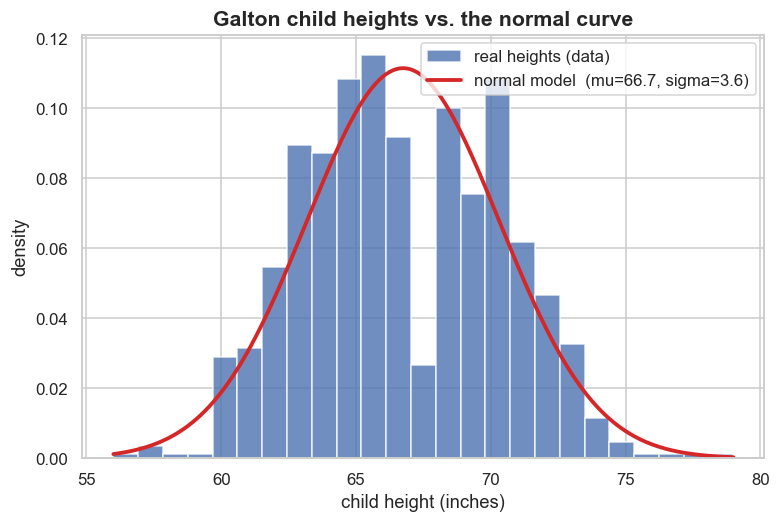

The red curve hugs the blue bars -> these heights are very nearly normal.


In [2]:
# Histogram of REAL heights (density=True so bar areas sum to 1, matching the curve)
fig, ax = plt.subplots()
ax.hist(heights, bins=25, density=True, color='#4c72b0',
        edgecolor='white', alpha=0.8, label='real heights (data)')

# The smooth normal curve built from the data's own mu and sd
x = np.linspace(heights.min(), heights.max(), 300)
ax.plot(x, stats.norm.pdf(x, mu, sd), color='#d62728', lw=2.5,
        label=f'normal model  (mu={mu:.1f}, sigma={sd:.1f})')

ax.set_xlabel('child height (inches)'); ax.set_ylabel('density')
ax.set_title('Galton child heights vs. the normal curve')
ax.legend(); plt.show()
print('The red curve hugs the blue bars -> these heights are very nearly normal.')

**The interpretation.** The smooth curve tracks the bars closely. That does **not** mean heights are *exactly* normal — no real data ever is. It means the normal model is a *good enough* description that we can borrow its math. And the math of the bell curve is generous: once a variable is roughly normal, the next two sections come almost for free.

## 2) The empirical rule: 68 – 95 – 99.7

For *any* normal curve, the same fixed fractions of the data fall within 1, 2, and 3 standard deviations of the mean. This is the famous **empirical rule**:

| Within… | Range | Normal says |
|---|---|---|
| **1 SD** | $\mu \pm \sigma$ | $\approx 68\%$ |
| **2 SD** | $\mu \pm 2\sigma$ | $\approx 95\%$ |
| **3 SD** | $\mu \pm 3\sigma$ | $\approx 99.7\%$ |

**The meaning.** "Almost everybody is within 2 SDs; practically everybody is within 3." It turns a standard deviation from an abstract number into an intuitive ruler.

Let's not *assert* it — let's **count** what fraction of the real children actually land in each band, and put the two columns side by side.

In [3]:
print(f"{'band':<12}{'data (counted)':>16}{'normal (theory)':>18}")
print('-' * 46)
theory = {1: 68.0, 2: 95.0, 3: 99.7}
for k in (1, 2, 3):
    lo, hi = mu - k * sd, mu + k * sd
    frac = ((heights >= lo) & (heights <= hi)).mean() * 100
    print(f"mu +/- {k} SD {frac:>14.1f}% {theory[k]:>16.1f}%")

band          data (counted)   normal (theory)
----------------------------------------------
mu +/- 1 SD           62.4%             68.0%
mu +/- 2 SD           97.6%             95.0%
mu +/- 3 SD           99.7%             99.7%


The 2-SD and 3-SD bands land almost spot on the textbook values; the 1-SD band comes in around **6 points under** 68% — a useful reminder that the empirical rule is an *approximation* and real data is never *perfectly* normal. Now let's **see** those bands painted onto the histogram.

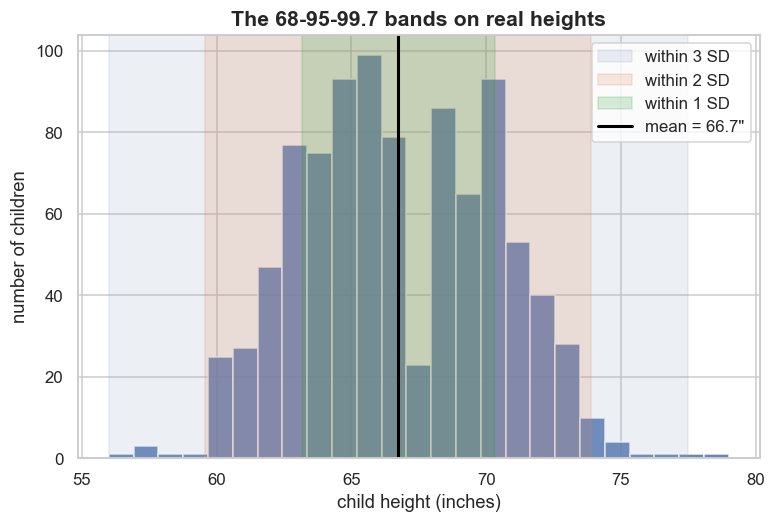

In [4]:
fig, ax = plt.subplots()
ax.hist(heights, bins=25, color='#4c72b0', edgecolor='white', alpha=0.85)

# Shade the 1/2/3 SD bands from widest (faintest) to narrowest (boldest)
band_colors = ['#9aa7c7', '#dd8452', '#2ca02c']
for k, c in zip((3, 2, 1), band_colors):
    ax.axvspan(mu - k * sd, mu + k * sd, color=c, alpha=0.18,
               label=f'within {k} SD')
ax.axvline(mu, color='black', lw=2, label=f'mean = {mu:.1f}"')

ax.set_xlabel('child height (inches)'); ax.set_ylabel('number of children')
ax.set_title('The 68-95-99.7 bands on real heights')
ax.legend(); plt.show()

## 3) The punchline: a z-score becomes a *probability*

Back in Lesson 2 we computed z-scores but stopped short — we could say a value was "2 SDs above the mean," yet we couldn't say *what fraction of the world is above it*. The normal model supplies the missing piece: the **cumulative distribution function (CDF)**.

**The math.** First convert the question to a z-score, then read off the area under the curve.

$$z = \frac{x - \mu}{\sigma}, \qquad P(\text{taller than } x) = \text{sf}(z) = 1 - \text{CDF}(z).$$

Here `stats.norm.cdf(z)` is the area to the **left** of $z$ (the fraction *below*), and `stats.norm.sf(z)` ("survival function") is the area to the **right** (the fraction *above*). Let's ask: **what fraction of these children are taller than 70 inches?** — and compare the normal prediction with the raw count.

In [5]:
cutoff = 70.0                                   # <- tinker: try 64, 72, 60
z = (cutoff - mu) / sd

normal_pct    = stats.norm.sf(z) * 100          # theory: area under the curve, right of z
empirical_pct = (heights > cutoff).mean() * 100 # reality: just count them

print(f"Question: what fraction of children are taller than {cutoff:.0f} inches?")
print(f"  z-score                = {z:.3f}  (i.e. {z:.2f} SDs above the mean)")
print(f"  NORMAL prediction      = {normal_pct:5.2f}%   (from the bell curve)")
print(f"  EMPIRICAL (counted)    = {empirical_pct:5.2f}%   (from the real data)")
print(f"  difference             = {abs(normal_pct - empirical_pct):5.2f} percentage points")

Question: what fraction of children are taller than 70 inches?
  z-score                = 0.909  (i.e. 0.91 SDs above the mean)
  NORMAL prediction      = 18.16%   (from the bell curve)
  EMPIRICAL (counted)    = 18.84%   (from the real data)
  difference             =  0.68 percentage points


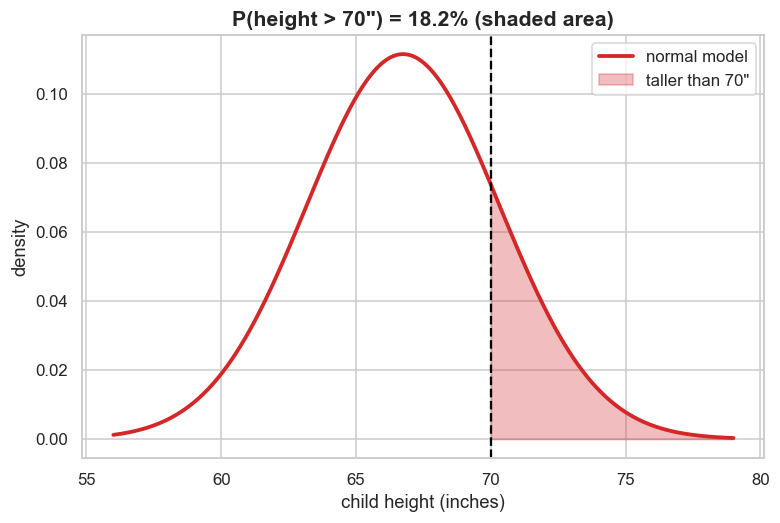

In [6]:
# Picture the question: shade the tail beyond the cutoff under the normal curve.
fig, ax = plt.subplots()
x = np.linspace(heights.min(), heights.max(), 400)
y = stats.norm.pdf(x, mu, sd)
ax.plot(x, y, color='#d62728', lw=2.5, label='normal model')
tail = x >= cutoff
ax.fill_between(x[tail], y[tail], color='#d62728', alpha=0.30,
                label=f'taller than {cutoff:.0f}"')
ax.axvline(cutoff, color='black', lw=1.5, ls='--')
ax.set_xlabel('child height (inches)'); ax.set_ylabel('density')
ax.set_title(f'P(height > {cutoff:.0f}") = {normal_pct:.1f}% (shaded area)')
ax.legend(); plt.show()

**The interpretation.** The bell curve predicts about **18%** and a direct head-count gives about **19%** — they essentially agree. *This is the new power.* When data is roughly normal, you no longer need the dataset in front of you to answer "how rare is this value?" — you need only $\mu$, $\sigma$, and a z-score. The same trick runs *backwards* too: ask "how tall must a child be to crack the top 10%?" and `stats.norm.ppf` (the **percentile function**) hands you the height.

In [7]:
# Run the trick BACKWARDS: from a percentile to a height.
top_pct = 0.90                                  # the 90th percentile = top 10% cutoff
z_p   = stats.norm.ppf(top_pct)                 # the z that leaves 90% below it
predicted = mu + z_p * sd                        # convert that z back to inches
actual    = heights.quantile(top_pct)            # the real 90th-percentile height

print(f"To be in the tallest 10%, the normal model says you need > {predicted:.1f} inches.")
print(f"The real data's 90th percentile is             {actual:.1f} inches.  (close!)")

To be in the tallest 10%, the normal model says you need > 71.3 inches.
The real data's 90th percentile is             71.5 inches.  (close!)


## 4) The standard normal $N(0,1)$ — and a peek at confidence intervals

Convert *every* value to its z-score and the whole bell collapses onto one universal curve: the **standard normal**, written $N(0,1)$ — mean $0$, standard deviation $1$. It's the master ruler that every normal distribution shares.

One number on it is worth remembering. The central **95%** of a normal distribution sits between $z = -1.96$ and $z = +1.96$:

$$P(-1.96 \le z \le 1.96) = 0.95.$$

In [8]:
z_star = stats.norm.ppf(0.975)   # the z with 97.5% below it -> leaves 2.5% in each tail
mid    = stats.norm.cdf(1.96) - stats.norm.cdf(-1.96)
print(f"95% of a normal curve lies within z = +/- {z_star:.2f}")
print(f"Check: area between -1.96 and +1.96 = {mid*100:.1f}%")

95% of a normal curve lies within z = +/- 1.96
Check: area between -1.96 and +1.96 = 95.0%


**The interpretation.** That magic **1.96** is the seed of nearly every "95%" you'll ever see quoted. In a few lessons it becomes the engine of a **95% confidence interval** — a range, built as roughly "estimate $\pm 1.96$ standard errors," that pins down an unknown true value. File 1.96 away; it's coming back.

## 5) Is it *really* normal? The Q-Q plot

Eyeballing a histogram is rough. The sharper tool is a **quantile-quantile (Q-Q) plot**: it sorts the data and plots each value against the value the normal model *expected* at that rank.

**How to read it:** if the points fall along a **straight line**, the data is close to normal. **Bends and S-curves reveal skew or fat tails** — places where reality departs from the bell.

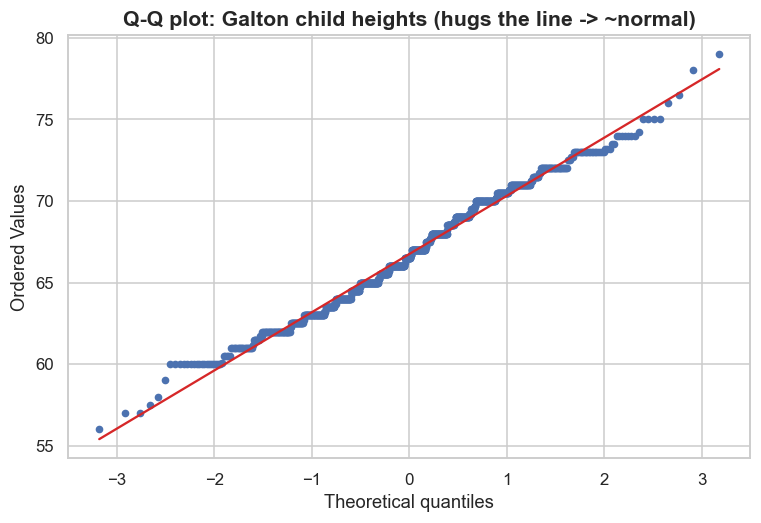

In [9]:
fig, ax = plt.subplots()
stats.probplot(heights, plot=ax)               # builds the Q-Q plot for us
ax.get_lines()[0].set_color('#4c72b0')         # the data points
ax.get_lines()[0].set_markersize(4)
ax.get_lines()[1].set_color('#d62728')         # the 'perfectly normal' reference line
ax.set_title('Q-Q plot: Galton child heights (hugs the line -> ~normal)')
plt.show()

The height points ride along the red line almost the whole way — visual confirmation that heights are close to normal. To see what a **failure** looks like, let's run the same plot on a famously *skewed* variable: borrowers' **annual income** from the Lending Club loans data.

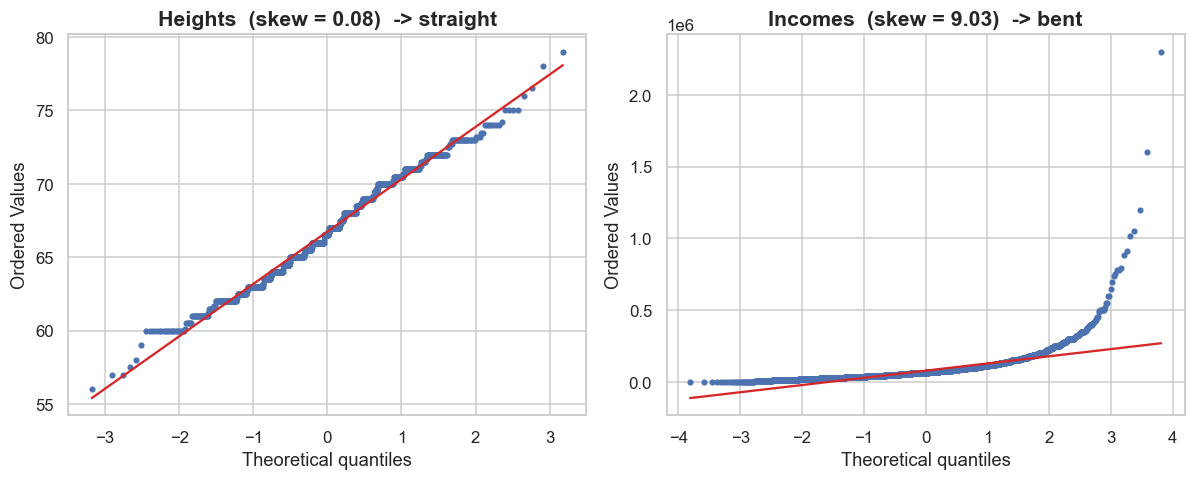

Heights: points on the line (normal).  Income: a sharp upward bend (right-skewed, NOT normal).


In [10]:
loans = sl.load_csv('loans.csv', url='https://www.openintro.org/data/csv/loans_full_schema.csv')
income = loans['annual_income'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
stats.probplot(heights, plot=axes[0])
axes[0].set_title(f'Heights  (skew = {heights.skew():.2f})  -> straight')
stats.probplot(income, plot=axes[1])
axes[1].set_title(f'Incomes  (skew = {income.skew():.2f})  -> bent')
for axx in axes:
    axx.get_lines()[0].set_color('#4c72b0'); axx.get_lines()[0].set_markersize(3)
    axx.get_lines()[1].set_color('#d62728')
plt.tight_layout(); plt.show()
print('Heights: points on the line (normal).  Income: a sharp upward bend (right-skewed, NOT normal).')

**The interpretation.** Heights are normal; income is emphatically not — it curves up and away because a few very high earners stretch the right tail. That contrast is the whole point: **the empirical rule and the z-to-probability trick only apply when the data is roughly normal.** Always check the shape before you trust the bell-curve math.

## Now you try

Predict the answer first, then change one thing and re-run:

1. In the section-3 cell, change `cutoff = 70.0` to **64.0**. Before running: will the *fraction taller* go up or down? Do the normal prediction and the count still agree?
2. In the same cell, set `cutoff = mu` (exactly the mean). What percentage do you expect to be taller? Run it and confirm the bell curve says ~50%.
3. In the backwards cell, change `top_pct = 0.90` to **0.99** (the top 1%). How tall must a child be? Does the normal model still match the data's real 99th percentile, or does the rare tail start to disagree?

## What you learned

- **The math:** a normal curve is fully described by two numbers, $\mu$ and $\sigma$, through $f(x)=\frac{1}{\sigma\sqrt{2\pi}}e^{-\frac12((x-\mu)/\sigma)^2}$.
- **The meaning:** the **empirical rule** says $\approx 68\%/95\%/99.7\%$ of values fall within 1/2/3 SDs of the mean — and counting real heights confirms it.
- **The power:** a **z-score** plus the normal **CDF** turns "how unusual?" into an actual **probability** or **percentile** — the piece Lesson 2 withheld.
- **The standard normal** $N(0,1)$ is the universal ruler; $\pm 1.96$ encloses the central 95% and seeds the confidence interval.
- **The caution:** a **Q-Q plot** checks normality — heights ride the line, skewed income bends away. The bell-curve tricks only work when the shape is actually normal.

**Next:** Lesson 10 reveals *why* the normal curve is everywhere — the **Central Limit Theorem**, where averages of samples turn normal even when the raw data is wildly skewed.

---

**← Previous:** [Lesson 8: Binomial & Poisson — counting events](08-binomial-poisson.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  **Next →:** [Lesson 10: Sampling distributions & the Central Limit Theorem](10-sampling-distributions-clt.ipynb)

**Same idea, another way:**  [Another dataset →](09-normal-distribution~another-dataset.ipynb)  ·  [The code behind it →](09-normal-distribution~the-code.ipynb)